In [5]:
import pandas as pd

# Load first file
df1 = pd.read_csv('Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

# Load second file
df2 = pd.read_csv('Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv')

# Load 3rd file
df3 = pd.read_csv('Friday-WorkingHours-Morning.pcap_ISCX.csv')
# Remove BENIGN rows
# df3_filtered = df3[df3[' Label'] != 'BENIGN']

# Load 4th file
df4 = pd.read_csv('Monday-WorkingHours.pcap_ISCX.csv')


# Load 5th file
df5 = pd.read_csv('Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv')
# Remove BENIGN rows
#df5_filtered = df5[df5[' Label'] != 'BENIGN']

# Load 6th file
df6 = pd.read_csv('Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv')

# Load 7th file
df7 = pd.read_csv('Tuesday-WorkingHours.pcap_ISCX.csv')

# Load 8th file
df8 = pd.read_csv('Wednesday-workingHours.pcap_ISCX.csv')



# List of all dataframes
dfs = [df1, df2, df3, df4,df5, df6, df7, df8]

# Merge all dataframes vertically (along rows)
merged_df = pd.concat(dfs, ignore_index=True)

# Check the merged dataframe
print(merged_df.columns)
# check the class distribution
class_counts = merged_df[' Label'].value_counts()
print("Class distribution:\n", class_counts)
print(merged_df.shape)



Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [6]:
# Strip leading/trailing spaces from column names
merged_df.columns = merged_df.columns.str.strip()

print(merged_df.columns)
print(merged_df.shape)


Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [7]:
# Count unique values in each column
num_unique = merged_df.nunique()

# Columns with only one unique value (useless for modeling)
one_value_cols = num_unique[num_unique == 1].index

# Drop those columns
merged_df = merged_df.drop(columns=one_value_cols)

# dropped column names
print("Dropped columns with only one unique value:")
print(list(one_value_cols))
print(merged_df.shape)

Dropped columns with only one unique value:
['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
(2830743, 71)


In [8]:
# Step 1: Count how many samples each class has
class_counts = merged_df['Label'].value_counts()

# Step 2: Select only the classes that have more than 1950 samples
selected_classes = class_counts[class_counts > 1950]
class_names = selected_classes.index

# Step 3: Filter the dataframe to keep only the selected classes
selected = merged_df[merged_df['Label'].isin(class_names)]

# Step 4: Balance the classes by sampling (max 5000 samples per class)
dfs = []
for name in class_names:
    df = selected[selected['Label'] == name]
    if len(df) > 2500:
        df = df.sample(n=5000, random_state=0)  # You can reduce n to 2500 if needed
    dfs.append(df)

# Step 5: Combine the balanced data into a new DataFrame
df = pd.concat(dfs, ignore_index=True)

# Update merged_df
merged_df = df.copy()

# Step 6: Show the new class distribution
merged_df['Label'].value_counts()
print(merged_df.shape)


(46966, 71)


In [9]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Convert the 'Label' column to numeric labels
merged_df['Label'] = label_encoder.fit_transform(merged_df['Label'])

# Now, you can check the class distribution with numeric labels
class_counts = merged_df['Label'].value_counts()
print("Class distribution:\n", class_counts)
print(merged_df.shape)

Class distribution:
 Label
0    5000
4    5000
8    5000
2    5000
3    5000
7    5000
9    5000
6    5000
5    5000
1    1966
Name: count, dtype: int64
(46966, 71)


In [10]:
# Import necessary libraries
import numpy as np

print(merged_df.shape)
# 1. Data Cleaning: Remove missing or inconsistent data
# Replace infinite values with NaN
merged_df.replace([float('inf'), float('-inf')], np.nan, inplace=True)
# Drop rows with NaN values
merged_df.dropna(inplace=True)

# Separate features and labels
X = merged_df.drop(columns=['Label'])
y = merged_df['Label']

print(X.shape)

print(y.shape)

print(y.value_counts())


(46966, 71)
(46930, 70)
(46930,)
Label
0    5000
2    5000
3    5000
9    5000
6    5000
5    5000
7    4998
8    4994
4    4982
1    1956
Name: count, dtype: int64


In [11]:
#2 data normalization
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Apply Standard Scaling directly
X_scaled_df = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X = X_scaled_df.copy()
# Now `X_scaled_df` contains standardized values (mean ~ 0, std ~ 1)
print(X.shape)
print(X.head())  # Check first few rows



(46930, 70)
   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0         -0.228973      -0.516362           0.257992                0.001534   
1         -0.228973      -0.652363          -0.282321               -0.062976   
2         -0.267650       0.376332          -0.390384               -0.191995   
3         -0.267650      -0.651916          -0.390384               -0.191995   
4          6.221176      -0.653174          -0.282321               -0.321015   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                    -0.029166                     0.004436   
1                    -0.105073                    -0.140112   
2                    -0.103289                    -0.129717   
3                    -0.113733                    -0.133290   
4                    -0.117554                    -0.140993   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
0               0.059788              -0.114484

In [12]:
from imblearn.over_sampling import SMOTE
from sklearn.utils import shuffle
print("Class distribution before SMOTE and shuffling:\n", y.value_counts())
# Apply SMOTE
smote = SMOTE(sampling_strategy="auto", random_state=0)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Convert to DataFrame for shuffling and reassigning
blnc_data = pd.DataFrame(X_resampled, columns=X.columns)
blnc_data['Label'] = y_resampled

# Shuffle the data
blnc_data = blnc_data.sample(frac=1, random_state=0).reset_index(drop=True)

# Assign back to X_resampled and y_resampled
X_resampled = blnc_data.drop('Label', axis=1)
y_resampled = blnc_data['Label']

# Check class distribution
print("Class distribution after SMOTE and shuffling:\n", y_resampled.value_counts())
print(X_resampled.shape)
print(y_resampled.shape)

Class distribution before SMOTE and shuffling:
 Label
0    5000
2    5000
3    5000
9    5000
6    5000
5    5000
7    4998
8    4994
4    4982
1    1956
Name: count, dtype: int64
Class distribution after SMOTE and shuffling:
 Label
8    5000
2    5000
1    5000
7    5000
5    5000
9    5000
4    5000
3    5000
0    5000
6    5000
Name: count, dtype: int64
(50000, 70)
(50000,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import numpy as np

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Evaluation function
def evaluate_model(name, y_true, y_pred, y_proba=None):
    print(f"\nðŸ” {name} Evaluation:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='macro'))
    print("Recall:", recall_score(y_true, y_pred, average='macro'))
    print("F1-Score:", f1_score(y_true, y_pred, average='macro'))
    if y_proba is not None:
        print("ROC AUC:", roc_auc_score(y_true, y_proba, multi_class='ovr'))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)
evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf)

# SVM
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
y_proba_svm = svm.predict_proba(X_test)
evaluate_model("Support Vector Machine", y_test, y_pred_svm, y_proba_svm)

# Neural Network replacement using scikit-learn MLP
nn = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=5,
    random_state=42
)
nn.fit(X_train, y_train)
y_pred_nn = nn.predict(X_test)
y_proba_nn = nn.predict_proba(X_test)
evaluate_model("Neural Network", y_test, y_pred_nn, y_proba_nn)


ðŸ” Random Forest Evaluation:
Accuracy: 0.9974
Precision: 0.9973776593800483
Recall: 0.997403148644785
F1-Score: 0.9973894129443002
ROC AUC: 0.9995975599477912

ðŸ” Support Vector Machine Evaluation:
Accuracy: 0.9808
Precision: 0.9808011295424178
Recall: 0.9805904260920938
F1-Score: 0.9803710900291399
ROC AUC: 0.9983433831681602


Epoch 1/10
1000/1000 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 8s 5ms/step - accuracy: 0.8542 - loss: 0.5577 - val_accuracy: 0.9750 - val_loss: 0.0981
Epoch 2/10
1000/1000 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 4s 4ms/step - accuracy: 0.9769 - loss: 0.0879 - val_accuracy: 0.9794 - val_loss: 0.0821
Epoch 3/10
1000/1000 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 6s 6ms/step - accuracy: 0.9814 - loss: 0.0724 - val_accuracy: 0.9805 - val_loss: 0.0763
Epoch 4/10
1000/1000 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 5s 5ms/step - accuracy: 0.9844 - loss: 0.0630 - val_accuracy: 0.9845 - val_loss: 0.0622
Epoch 5/10
1000/1000 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 5s 4ms/step - accuracy: 0.9860 - loss: 0.0536 - val_accuracy: 0.9849 - val_loss: 0.0667
Epoch 6/10
1000/1000 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 5s 5ms/step - accuracy: 0.9855 - loss: 0.0540 - val_accuracy: 0.9804

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from scipy.stats import ttest_rel
import numpy as np

# Convert data to numpy arrays
X_np = X_resampled.values if hasattr(X_resampled, 'values') else X_resampled
y_np = y_resampled.values if hasattr(y_resampled, 'values') else y_resampled

metrics_storage = {
    'Random Forest': {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []},
    'SVM': {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []},
    'Neural Network': {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []}
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, val_idx in kf.split(X_np):
    X_train_fold, X_val = X_np[train_idx], X_np[val_idx]
    y_train_fold, y_val = y_np[train_idx], y_np[val_idx]

    models = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'SVM': SVC(kernel='rbf', probability=True, random_state=42),
        'Neural Network': MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation='relu',
            solver='adam',
            max_iter=50,
            early_stopping=True,
            validation_fraction=0.2,
            n_iter_no_change=5,
            random_state=42
        )
    }

    for model_name, model in models.items():
        model.fit(X_train_fold, y_train_fold)
        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)

        metrics_storage[model_name]['accuracy'].append(accuracy_score(y_val, y_pred))
        metrics_storage[model_name]['precision'].append(
            precision_score(y_val, y_pred, average='macro', zero_division=0)
        )
        metrics_storage[model_name]['recall'].append(
            recall_score(y_val, y_pred, average='macro', zero_division=0)
        )
        metrics_storage[model_name]['f1'].append(
            f1_score(y_val, y_pred, average='macro', zero_division=0)
        )
        if len(np.unique(y_val)) == 2:
            metrics_storage[model_name]['roc_auc'].append(roc_auc_score(y_val, y_proba[:, 1]))
        else:
            metrics_storage[model_name]['roc_auc'].append(
                roc_auc_score(y_val, y_proba, multi_class='ovr')
            )

print("================= Cross-Validation Results =================")
for model in metrics_storage:
    print(f"\nðŸ” {model} Performance:")
    for metric in metrics_storage[model]:
        mean = np.mean(metrics_storage[model][metric])
        std = np.std(metrics_storage[model][metric])
        print(f"{metric.capitalize()}: {mean:.4f} Â± {std:.4f}")

print("\n\n================= Statistical Significance Tests =================")
models = list(metrics_storage.keys())
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

for metric in metrics:
    print(f"\nðŸ“Š {metric.upper()} COMPARISONS:")
    for i in range(len(models)):
        for j in range(i + 1, len(models)):
            model1, model2 = models[i], models[j]
            t_stat, p_value = ttest_rel(
                metrics_storage[model1][metric], metrics_storage[model2][metric]
            )
            print(f"\n{model1} vs {model2}:")
            print(f"  {model1}: {np.mean(metrics_storage[model1][metric]):.4f}")
            print(f"  {model2}: {np.mean(metrics_storage[model2][metric]):.4f}")
            print(f"  t-statistic = {t_stat:.4f}, p-value = {p_value:.6f}")
            if p_value < 0.05:
                better = model1 if np.mean(metrics_storage[model1][metric]) > np.mean(metrics_storage[model2][metric]) else model2
                print(f"  SIGNIFICANT (p < 0.05) -> {better} performs better")
            else:
                print("  Not significant (p >= 0.05)")

313/313 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 1s 3ms/step


313/313 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 1s 3ms/step


313/313 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 1s 2ms/step


313/313 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 1s 2ms/step


313/313 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 1s 2ms/step
================= Cross-Validation Results =================

ðŸ” Random Forest Performance:
Accuracy: 0.9966 Â± 0.0008
Precision: 0.9966 Â± 0.0008
Recall: 0.9966 Â± 0.0008
F1: 0.9966 Â± 0.0008
Roc_auc: 0.9998 Â± 0.0001

ðŸ” SVM Performance:
Accuracy: 0.9772 Â± 0.0019
Precision: 0.9773 Â± 0.0018
Recall: 0.9772 Â± 0.0018
F1: 0.9768 Â± 0.0018
Roc_auc: 0.9982 Â± 0.0002

ðŸ” Neural Network Performance:
Accuracy: 0.9886 Â± 0.0017
Precision: 0.9886 Â± 0.0017
Recall: 0.9886 Â± 0.0017
F1: 0.9885 Â± 0.0017
Roc_auc: 0.9995 Â± 0.0001


================= Statistical Significance Tests =================

ðŸ“Š ACCURACY COMPARISONS:

Random Forest vs SVM:
  Random Forest: 0.9966 Â± 0.0008
  SVM: 0.9772 Â± 0.0019
  t-statistic = 24.6754, p-value = 0.000016
  âœ… SIGNIFICANT (p < 0.05) â†’ Random Forest performs better

Random Forest vs Neural Network:
  Random Forest: 0.9966 Â± 0.0008
  Neural Network: 0.9886 Â± 0.0017

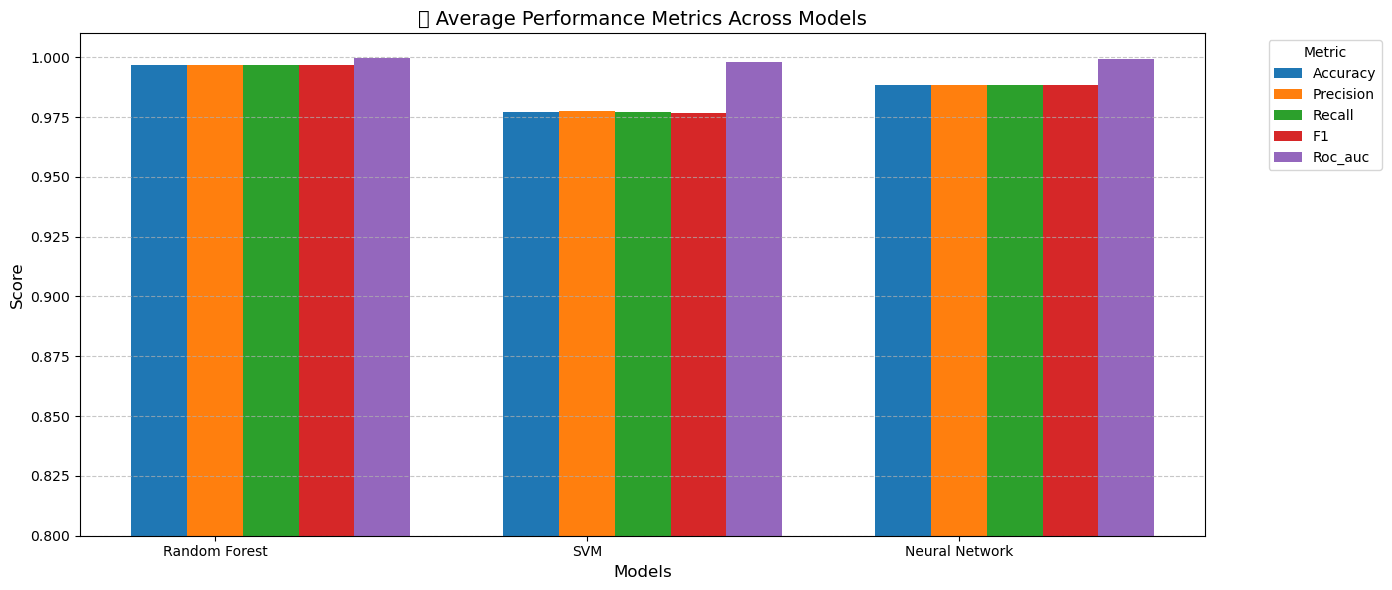

In [16]:
# ===== VISUALIZATION: Average Metric Scores per Model =====
import matplotlib.pyplot as plt
import numpy as np

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
models = list(metrics_storage.keys())

# Calculate mean scores
mean_scores = {
    metric: [np.mean(metrics_storage[model][metric]) for model in models]
    for metric in metrics
}

# Plotting
plt.figure(figsize=(14, 6))
x = np.arange(len(models))
width = 0.15

for idx, metric in enumerate(metrics):
    plt.bar(x + idx * width, mean_scores[metric], width, label=metric.capitalize())

plt.xlabel("Models", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title("ðŸ” Average Performance Metrics Across Models", fontsize=14)
plt.xticks(x + width, models)
plt.ylim(0.8, 1.01)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


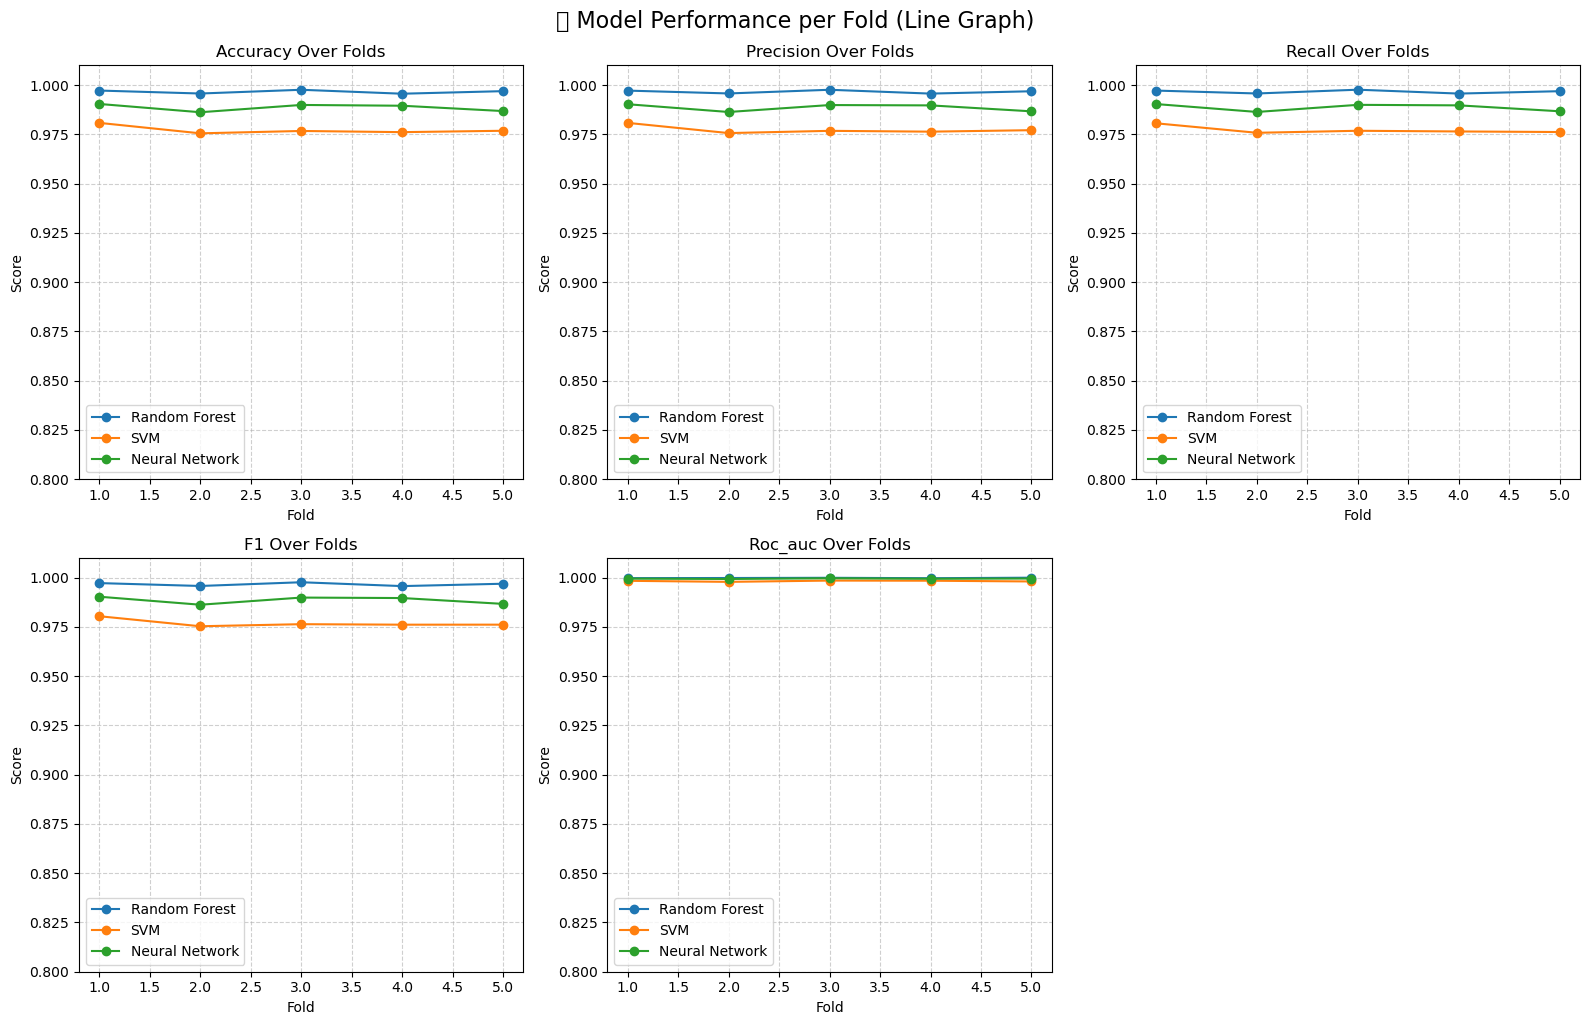

In [17]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
models = list(metrics_storage.keys())
folds = list(range(1, 6))  # Since you're using 5-fold CV

plt.figure(figsize=(16, 10))

for idx, metric in enumerate(metrics, 1):
    plt.subplot(2, 3, idx)  # Create subplots for each metric
    for model in models:
        scores = metrics_storage[model][metric]
        plt.plot(folds, scores, marker='o', label=model)

    plt.title(f'{metric.capitalize()} Over Folds', fontsize=12)
    plt.xlabel('Fold')
    plt.ylabel('Score')
    plt.ylim(0.8, 1.01)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

plt.tight_layout()
plt.suptitle("ðŸ“ˆ Model Performance per Fold (Line Graph)", fontsize=16, y=1.02)
plt.show()


In [1]:
import numpy as np
import pandas as pd

from sklearn import preprocessing
from sklearn.preprocessing import (StandardScaler, OrdinalEncoder, LabelEncoder, 
                                    MinMaxScaler, OneHotEncoder, Normalizer, 
                                    MaxAbsScaler, RobustScaler, PowerTransformer)



In [2]:
feature = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent","hot",
           "num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root",
           "num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login",
           "is_guest_login","count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
           "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count", 
           "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
           "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
           "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"]

# file path
train_path = 'KDDTrain+.txt'


# Let's load the training data
train_data = pd.read_csv(train_path, names=feature)
print("First 5 rows:")
print(train_data.head())



First 5 rows:
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   


In [3]:
# removing the 'difficulty' column
train_data.drop(['difficulty'], axis=1, inplace=True)
print("New shape:", train_data.shape)
train_data.info()
print(train_data.describe().T)

# Distribution of attack labels
print("Distribution of attack labels:")
print(train_data['label'].value_counts())

New shape: (125973, 42)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              12597

In [4]:
# Function to convert attack labels into desired categories
def change_label(df):
    df.label.replace(['apache2','back','land','neptune','mailbomb','pod','processtable','smurf','teardrop','udpstorm','worm'],
                     'Dos', inplace=True)
    df.label.replace(['ftp_write','guess_passwd','httptunnel','imap','multihop','named','phf','sendmail',
                      'snmpgetattack','snmpguess','spy','warezclient','warezmaster','xlock','xsnoop'],
                     'R2L', inplace=True)      
    df.label.replace(['ipsweep','mscan','nmap','portsweep','saint','satan'],
                     'Probe', inplace=True)
    df.label.replace(['buffer_overflow','loadmodule','perl','ps','rootkit','sqlattack','xterm'],
                     'U2R', inplace=True)

change_label(train_data)
print("After the labels are updated:")
print(train_data['label'].value_counts())

After the labels are updated:
label
normal    67343
Dos       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [5]:
# Step 1: Count the number of samples in each class
print(train_data['label'].value_counts())
class_counts = train_data['label'].value_counts()

# Step 2: Downsample if class count > 15000
dfs = []
for cls, count in class_counts.items():
    cls_df = train_data[train_data['label'] == cls]
    if count > 12000:
        cls_df = cls_df.sample(n=12000, random_state=42)
    dfs.append(cls_df)

# Step 3: Combine into a single DataFrame and shuffle
train_data = pd.concat(dfs, ignore_index=True)
train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)

# Step 4: Show final class distribution
print(train_data['label'].value_counts())
print("New shape of train_data:", train_data.shape)


label
normal    67343
Dos       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64
label
Dos       12000
normal    12000
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64
New shape of train_data: (36703, 42)


In [6]:
# Creating a copy of the data containing multi-class labels
multi_data = train_data.copy()
multi_label = pd.DataFrame(multi_data['label'])


In [7]:
# using StandardScaler to normalize the numerical columns
std_scaler = StandardScaler()
def standardization(df, cols):
    for col in cols:
        arr = df[col].values
        df[col] = std_scaler.fit_transform(arr.reshape(-1, 1))
    return df

numeric_col = multi_data.select_dtypes(include='number').columns
data = standardization(multi_data, numeric_col)

In [8]:
# Converting labels to numerical form (0,1,2,3,4: e.g., Dos, normal, Probe, R2L, U2R)
le2 = LabelEncoder()
multi_data['intrusion'] = le2.fit_transform(multi_data['label'])
print("Encoded 'intrusion' distribution:")
print(pd.Series(multi_data['intrusion']).value_counts())


# Dropping the original 'label' column
multi_data.drop(labels=['label'], axis=1, inplace=True)

# One-hot encoding for categorical columns (protocol_type, service, flag)
multi_data = pd.get_dummies(multi_data, columns=['protocol_type','service','flag'], prefix="", prefix_sep="")


Encoded 'intrusion' distribution:
intrusion
0    12000
4    12000
1    11656
2      995
3       52
Name: count, dtype: int64


In [9]:
# Separating the features and label variables
X_data = multi_data.drop(labels=['intrusion'], axis=1)
y_data = multi_data['intrusion']

print('X_data shape:', X_data.shape, '\ny_data shape:', y_data.shape)

X_data shape: (36703, 121) 
y_data shape: (36703,)


In [10]:
from imblearn.over_sampling import SMOTE

# First, split the data into train and test (before applying SMOTE)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42, stratify=y_data)

# Apply SMOTE only to the training data
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Original training data shape:", y_train.value_counts())
print("Resampled training data shape:", y_train_res.value_counts())


Original training data shape: intrusion
4    9600
0    9600
1    9325
2     796
3      41
Name: count, dtype: int64
Resampled training data shape: intrusion
4    9600
1    9600
2    9600
0    9600
3    9600
Name: count, dtype: int64


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import numpy as np

# Evaluation Function
def evaluate_model(name, y_true, y_pred, y_proba=None):
    print(f"\nðŸ” {name} Evaluation:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='macro'))
    print("Recall:", recall_score(y_true, y_pred, average='macro'))
    print("F1-Score:", f1_score(y_true, y_pred, average='macro'))
    if y_proba is not None:
        print("ROC AUC:", roc_auc_score(y_true, y_proba, multi_class='ovr'))

# 1. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)
evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf)

# 2. SVM
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_res, y_train_res)
y_pred_svm = svm.predict(X_test)
y_proba_svm = svm.predict_proba(X_test)
evaluate_model("Support Vector Machine", y_test, y_pred_svm, y_proba_svm)

# 3. Neural Network replacement using scikit-learn MLP
nn = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=5,
    random_state=42
)
nn.fit(X_train_res, y_train_res)
y_pred_nn = nn.predict(X_test)
y_proba_nn = nn.predict_proba(X_test)
evaluate_model("Neural Network", y_test, y_pred_nn, y_proba_nn)


ðŸ” Random Forest Evaluation:
Accuracy: 0.9986377877673341
Precision: 0.9963843132036304
Recall: 0.9773789478965359
F1-Score: 0.9864474488998066
ROC AUC: 0.9999427511403368

ðŸ” Support Vector Machine Evaluation:
Accuracy: 0.9667620215229533
Precision: 0.7608163997997865
Recall: 0.8872667232755174
F1-Score: 0.8028146535850158
ROC AUC: 0.9980548277027423

ðŸ” Neural Network Evaluation:
Accuracy: 0.9886936384688735
Precision: 0.8305622813675232
Recall: 0.9666649548295277
F1-Score: 0.8710307951963806
ROC AUC: 0.9883435912061806


In [26]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from scipy.stats import ttest_rel
import numpy as np

# Convert to numpy arrays and correct dtypes
X = X_train_res.values if hasattr(X_train_res, 'values') else X_train_res
y = y_train_res.values if hasattr(y_train_res, 'values') else y_train_res
X = X.astype(np.float32)
y = y.astype(np.int32)

# Metrics storage
metrics_storage = {
    'Random Forest': {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []},
    'SVM': {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []},
    'Neural Network': {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []}
}

# 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, val_idx in kf.split(X):
    X_train_fold, X_val = X[train_idx], X[val_idx]
    y_train_fold, y_val = y[train_idx], y[val_idx]

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train_fold, y_train_fold)
    y_pred = rf.predict(X_val)
    y_proba = rf.predict_proba(X_val)
    metrics_storage['Random Forest']['accuracy'].append(accuracy_score(y_val, y_pred))
    metrics_storage['Random Forest']['precision'].append(precision_score(y_val, y_pred, average='macro'))
    metrics_storage['Random Forest']['recall'].append(recall_score(y_val, y_pred, average='macro'))
    metrics_storage['Random Forest']['f1'].append(f1_score(y_val, y_pred, average='macro'))
    metrics_storage['Random Forest']['roc_auc'].append(roc_auc_score(y_val, y_proba, multi_class='ovr'))

    # SVM
    svm = SVC(kernel='rbf', probability=True, random_state=42)
    svm.fit(X_train_fold, y_train_fold)
    y_pred = svm.predict(X_val)
    y_proba = svm.predict_proba(X_val)
    metrics_storage['SVM']['accuracy'].append(accuracy_score(y_val, y_pred))
    metrics_storage['SVM']['precision'].append(precision_score(y_val, y_pred, average='macro'))
    metrics_storage['SVM']['recall'].append(recall_score(y_val, y_pred, average='macro'))
    metrics_storage['SVM']['f1'].append(f1_score(y_val, y_pred, average='macro'))
    metrics_storage['SVM']['roc_auc'].append(roc_auc_score(y_val, y_proba, multi_class='ovr'))

    # Neural Network replacement using scikit-learn MLP
    nn = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        max_iter=50,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=5,
        random_state=42
    )
    nn.fit(X_train_fold, y_train_fold)
    y_proba = nn.predict_proba(X_val)
    y_pred = nn.predict(X_val)
    metrics_storage['Neural Network']['accuracy'].append(accuracy_score(y_val, y_pred))
    metrics_storage['Neural Network']['precision'].append(precision_score(y_val, y_pred, average='macro'))
    metrics_storage['Neural Network']['recall'].append(recall_score(y_val, y_pred, average='macro'))
    metrics_storage['Neural Network']['f1'].append(f1_score(y_val, y_pred, average='macro'))
    metrics_storage['Neural Network']['roc_auc'].append(roc_auc_score(y_val, y_proba, multi_class='ovr'))

# Results Summary
print("================= Cross-Validation Results =================")
for model in metrics_storage:
    print(f"\nðŸ” {model} Performance:")
    for metric in metrics_storage[model]:
        mean_score = np.mean(metrics_storage[model][metric])
        std_score = np.std(metrics_storage[model][metric])
        print(f"{metric.capitalize()}: {mean_score:.4f} Â± {std_score:.4f}")

# Statistical Testing
print("\n\n================= Statistical Significance Tests =================")
models = list(metrics_storage.keys())
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

for metric in metrics:
    print(f"\nðŸ“Š {metric.upper()} COMPARISONS:")
    for i in range(len(models)):
        for j in range(i + 1, len(models)):
            model1, model2 = models[i], models[j]
            scores1 = metrics_storage[model1][metric]
            scores2 = metrics_storage[model2][metric]
            t_stat, p_value = ttest_rel(scores1, scores2)
            print(f"\n{model1} vs {model2}:")
            print(f"  {model1}: {np.mean(scores1):.4f} Â± {np.std(scores1):.4f}")
            print(f"  {model2}: {np.mean(scores2):.4f} Â± {np.std(scores2):.4f}")
            print(f"  t-statistic = {t_stat:.4f}, p-value = {p_value:.6f}")
            if p_value < 0.05:
                better = model1 if np.mean(scores1) > np.mean(scores2) else model2
                print(f"  SIGNIFICANT (p < 0.05) -> {better} performs better")
            else:
                print("  Not significant (p >= 0.05)")

================= Cross-Validation Results =================

ðŸ” Random Forest Performance:
Accuracy: 0.9988 Â± 0.0001
Precision: 0.9987 Â± 0.0001
Recall: 0.9987 Â± 0.0001
F1: 0.9987 Â± 0.0001
Roc_auc: 1.0000 Â± 0.0000

ðŸ” SVM Performance:
Accuracy: 0.9648 Â± 0.0011
Precision: 0.9665 Â± 0.0007
Recall: 0.9648 Â± 0.0009
F1: 0.9650 Â± 0.0009
Roc_auc: 0.9983 Â± 0.0001

ðŸ” Neural Network Performance:
Accuracy: 0.9905 Â± 0.0018
Precision: 0.9906 Â± 0.0017
Recall: 0.9905 Â± 0.0017
F1: 0.9905 Â± 0.0017
Roc_auc: 0.9995 Â± 0.0003


================= Statistical Significance Tests =================

ðŸ“Š ACCURACY COMPARISONS:

Random Forest vs SVM:
  Random Forest: 0.9988 Â± 0.0001
  SVM: 0.9648 Â± 0.0011
  t-statistic = 68.1715, p-value = 0.000000
  SIGNIFICANT (p < 0.05) -> Random Forest performs better

Random Forest vs Neural Network:
  Random Forest: 0.9988 Â± 0.0001
  Neural Network: 0.9905 Â± 0.0018
  t-statistic = 9.4793, p-value = 0.000691
  SIGNIFICANT (p < 0.05) -> Random Forest 

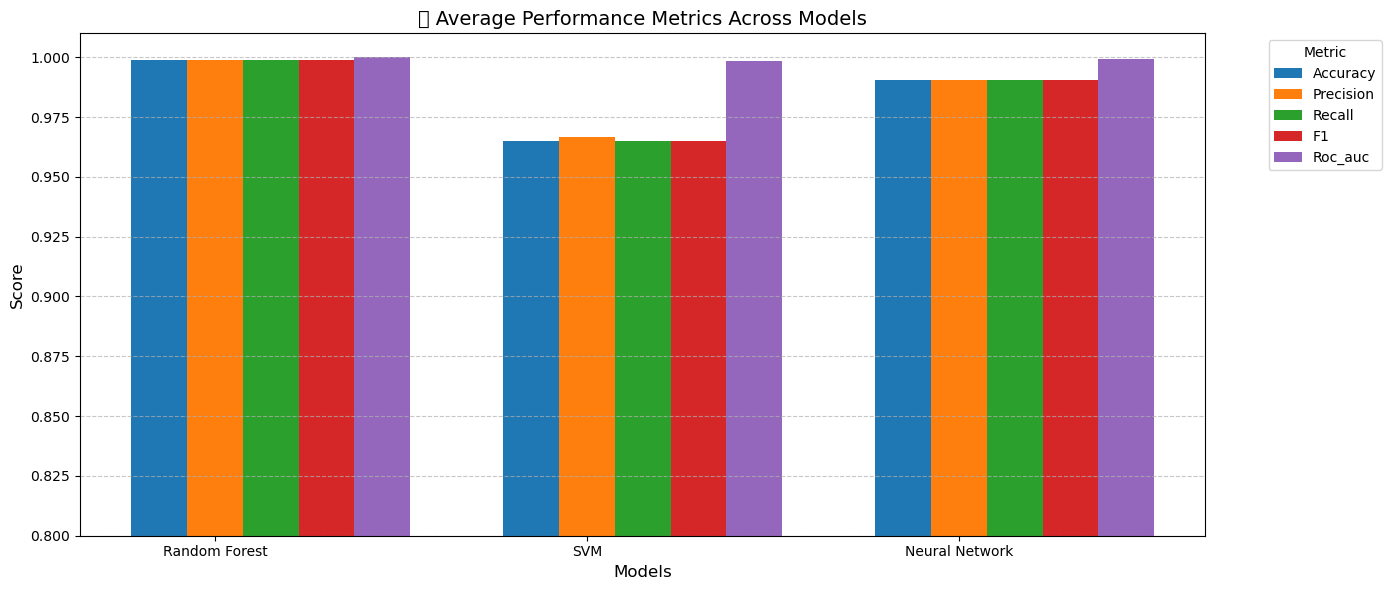

In [14]:
# ===== VISUALIZATION: Average Metric Scores per Model =====
import matplotlib.pyplot as plt
import numpy as np

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
models = list(metrics_storage.keys())

# Calculate mean scores
mean_scores = {
    metric: [np.mean(metrics_storage[model][metric]) for model in models]
    for metric in metrics
}

# Plotting
plt.figure(figsize=(14, 6))
x = np.arange(len(models))
width = 0.15

for idx, metric in enumerate(metrics):
    plt.bar(x + idx * width, mean_scores[metric], width, label=metric.capitalize())

plt.xlabel("Models", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title("ðŸ” Average Performance Metrics Across Models", fontsize=14)
plt.xticks(x + width, models)
plt.ylim(0.8, 1.01)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


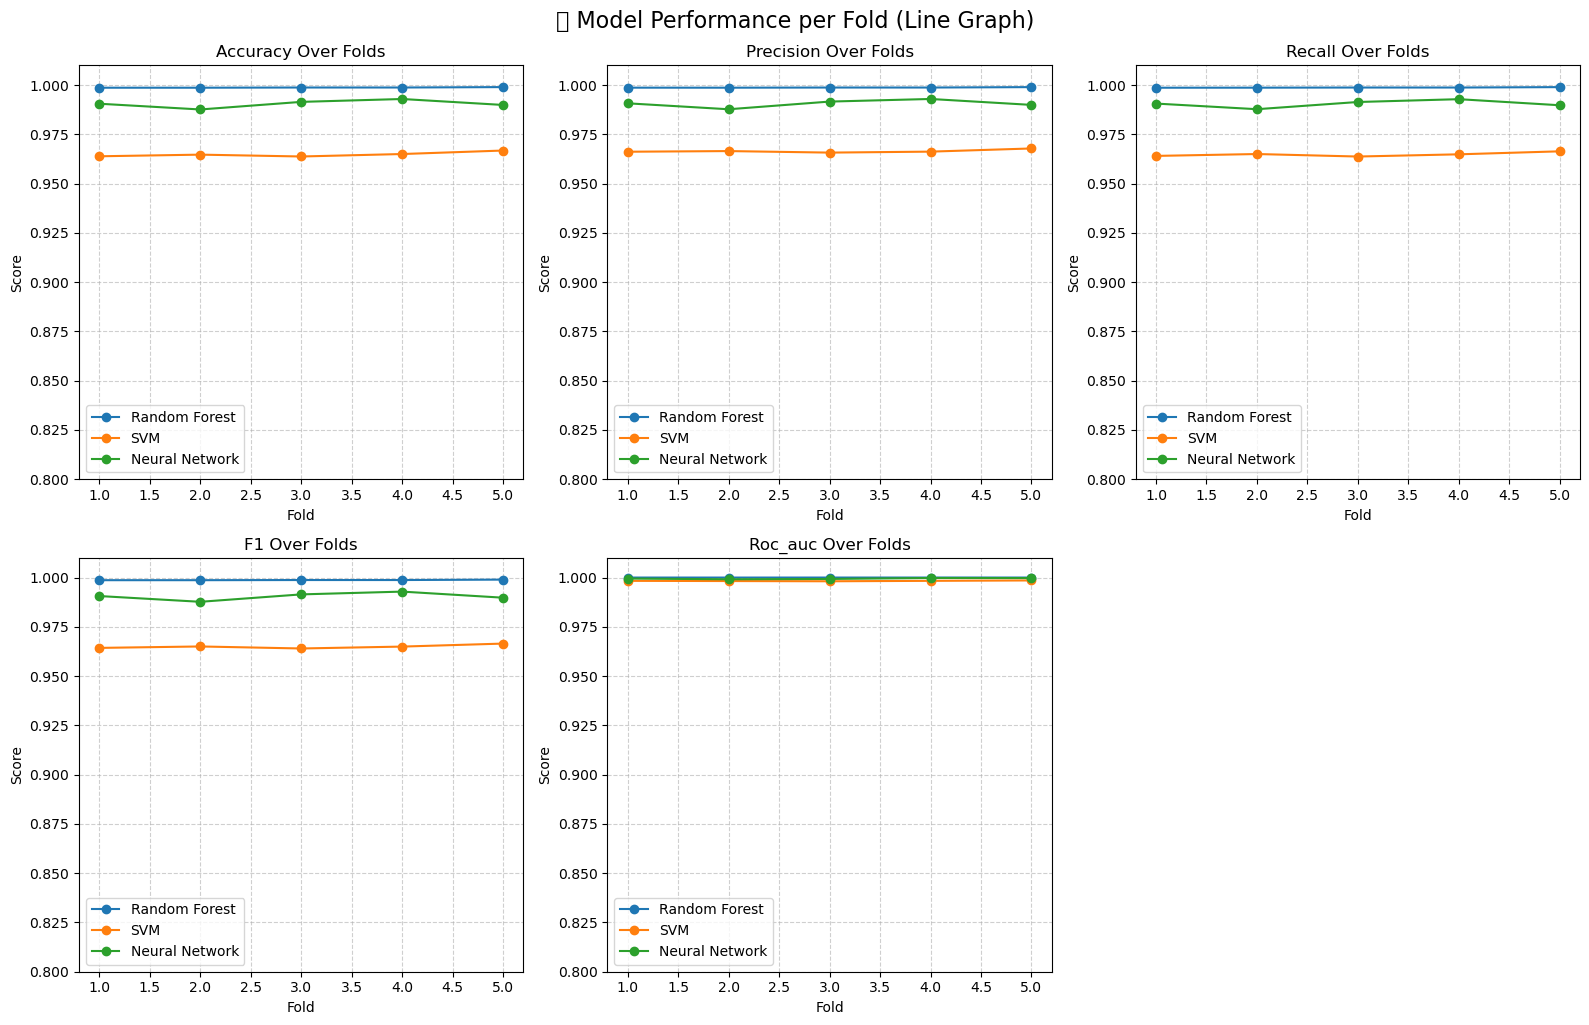

In [15]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
models = list(metrics_storage.keys())
folds = list(range(1, 6))  # Since you're using 5-fold CV

plt.figure(figsize=(16, 10))

for idx, metric in enumerate(metrics, 1):
    plt.subplot(2, 3, idx)  # Create subplots for each metric
    for model in models:
        scores = metrics_storage[model][metric]
        plt.plot(folds, scores, marker='o', label=model)

    plt.title(f'{metric.capitalize()} Over Folds', fontsize=12)
    plt.xlabel('Fold')
    plt.ylabel('Score')
    plt.ylim(0.8, 1.01)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

plt.tight_layout()
plt.suptitle("ðŸ“ˆ Model Performance per Fold (Line Graph)", fontsize=16, y=1.02)
plt.show()


In [16]:
import pandas as pd

# Load the UNSW-NB15 training set
df = pd.read_parquet('UNSW_NB15_training-set.parquet')

# Display basic info to confirm
print("âœ… Dataset Loaded Successfully!")
print(df.shape)
print(df.head())


âœ… Dataset Loaded Successfully!
(175341, 36)
        dur proto service state  spkts  dpkts  sbytes  dbytes       rate  \
0  0.121478   tcp       -   FIN      6      4     258     172  74.087486   
1  0.649902   tcp       -   FIN     14     38     734   42014  78.473373   
2  1.623129   tcp       -   FIN      8     16     364   13186  14.170161   
3  1.681642   tcp     ftp   FIN     12     12     628     770  13.677108   
4  0.449454   tcp       -   FIN     10      6     534     268  33.373825   

          sload  ...  trans_depth  response_body_len  ct_src_dport_ltm  \
0  14158.942383  ...            0                  0                 1   
1   8395.112305  ...            0                  0                 1   
2   1572.271851  ...            0                  0                 1   
3   2740.178955  ...            0                  0                 1   
4   8561.499023  ...            0                  0                 2   

   ct_dst_sport_ltm  is_ftp_login  ct_ftp_cmd  ct_fl

In [17]:
print(df['label'].value_counts())
print(df['attack_cat'].value_counts())
print(df.info())

label
1    119341
0     56000
Name: count, dtype: int64
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   dur                175341 non-null  float32 
 1   proto              175341 non-null  category
 2   service            175341 non-null  category
 3   state              175341 non-null  category
 4   spkts              175341 non-null  int16   
 5   dpkts              175341 non-null  int16   
 6   sbytes             175341 non-null  int32   
 7   dbytes             175341 non-null  int32   
 8   rate               175341 non-null  float32 
 9   s

In [18]:
# Check number of duplicates before removing
duplicates = df.duplicated().sum()
print(f"ðŸ” Duplicate rows before removal: {duplicates}")

# Remove duplicate rows
df = df.drop_duplicates()

# Check shape after removal
print(f"âœ… Duplicates removed. New shape: {df.shape}")
print(df['label'].value_counts())
print(df['attack_cat'].value_counts())

ðŸ” Duplicate rows before removal: 78519
âœ… Duplicates removed. New shape: (96822, 36)
label
0    48894
1    47928
Name: count, dtype: int64
attack_cat
Normal            48894
Exploits          19360
Fuzzers           14082
Reconnaissance     6000
DoS                3369
Generic            1800
Backdoor           1121
Analysis           1119
Shellcode           954
Worms               123
Name: count, dtype: int64


In [19]:
df = df.drop(columns=['attack_cat'])
print(f"New shape: {df.shape}")

New shape: (96822, 35)


In [20]:
# Separate the data into two classes based on the label
class_0 = df[df['label'] == 0]
class_1 = df[df['label'] == 1]

# Downsample each class to 22,000 rows
class_0_downsampled = class_0.sample(n=15000, random_state=42)
class_1_downsampled = class_1.sample(n=15000, random_state=42)

# Combine the downsampled data
df = pd.concat([class_0_downsampled, class_1_downsampled])

# Shuffle the combined dataset and reset the index
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check the shape to confirm
print(f"Balanced data shape: {df.shape}")
print(df['label'].value_counts())


Balanced data shape: (30000, 35)
label
0    15000
1    15000
Name: count, dtype: int64


In [21]:
print(f"shape before encoding: {df.shape}")
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


# One-hot encode those columns
df = pd.get_dummies(df, columns=categorical_cols)

print("Categorical columns:", categorical_cols)

# Check final shape and columns
print(f"Final shape after encoding: {df.shape}")
print(df['label'].value_counts())

shape before encoding: (30000, 35)
Categorical columns: ['proto', 'service', 'state']
Final shape after encoding: (30000, 187)
label
0    15000
1    15000
Name: count, dtype: int64


In [22]:
# Separate features and labels
X = df.drop(columns=['label'])
y = df['label']

print(X.shape)

print(y.shape)

print(y.value_counts())



(30000, 186)
(30000,)
label
0    15000
1    15000
Name: count, dtype: int64


In [23]:
#2 data normalization
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Apply Standard Scaling directly
X_scaled_df = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X = X_scaled_df.copy()
# âœ… Now `X_scaled_df` contains standardized values (mean ~ 0, std ~ 1)
print(X.shape)
print(X.head())  # Check first few rows



(30000, 186)
        dur     spkts     dpkts    sbytes    dbytes      rate     sload  \
0 -0.253449  0.239826  0.360233 -0.045638  0.276115 -0.200085 -0.188205   
1  0.086109 -0.125315 -0.189478 -0.060959 -0.148526 -0.251879 -0.193564   
2 -0.107171 -0.125315 -0.204748 -0.062403 -0.149030 -0.251779 -0.193558   
3  0.282053 -0.125315 -0.097860 -0.061159 -0.053407 -0.251870 -0.193571   
4 -0.258844 -0.114575 -0.158939 -0.060191 -0.137356 -0.188230 -0.183785   

      dload     sloss     dloss  ...  service_ssl  state_CON  state_ECO  \
0  4.924641 -0.019994  0.338251  ...    -0.029452  -0.357519  -0.005774   
1 -0.377423 -0.075228 -0.176413  ...    -0.029452  -0.357519  -0.005774   
2 -0.377164 -0.075228 -0.176413  ...    -0.029452  -0.357519  -0.005774   
3 -0.364688 -0.075228 -0.079913  ...    -0.029452  -0.357519  -0.005774   
4  0.903532 -0.053134 -0.128163  ...    -0.029452  -0.357519  -0.005774   

   state_FIN  state_INT  state_PAR  state_REQ  state_RST  state_URN  state_no  
0   0

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import numpy as np

# Use correct variables from the latest setup
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(y_train.shape)

# Evaluation function for binary classification
def evaluate_model(name, y_true, y_pred, y_proba=None):
    print(f"\nðŸ” {name} Evaluation:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-Score:", f1_score(y_true, y_pred))
    if y_proba is not None:
        print("ROC AUC:", roc_auc_score(y_true, y_proba[:, 1]))

# 1. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)
evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf)

# 2. SVM
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
y_proba_svm = svm.predict_proba(X_test)
evaluate_model("Support Vector Machine", y_test, y_pred_svm, y_proba_svm)

# 3. Neural Network replacement using scikit-learn MLP
nn = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=5,
    random_state=42
)
nn.fit(X_train, y_train)
y_pred_nn = nn.predict(X_test)
y_proba_nn = nn.predict_proba(X_test)
evaluate_model("Neural Network", y_test, y_pred_nn, y_proba_nn)

(24000, 186)
(24000,)

ðŸ” Random Forest Evaluation:
Accuracy: 0.912
Precision: 0.8801251956181534
Recall: 0.9509638146770375
F1-Score: 0.9141742522756827
ROC AUC: 0.9732683414625961

ðŸ” Support Vector Machine Evaluation:
Accuracy: 0.8961666666666667
Precision: 0.8349598163030999
Recall: 0.9837673317551573
F1-Score: 0.903275888837137
ROC AUC: 0.9159431198698488

ðŸ” Neural Network Evaluation:
Accuracy: 0.8985
Precision: 0.8402898550724638
Recall: 0.9803855258708151
F1-Score: 0.9049477134384267
ROC AUC: 0.9614484686909566


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from scipy.stats import ttest_rel
import numpy as np

X_np = X.values if hasattr(X, 'values') else X
y_np = y.values if hasattr(y, 'values') else y
metrics_storage = {
    'Random Forest': {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []},
    'SVM': {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []},
    'Neural Network': {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []}
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, val_idx in kf.split(X_np):
    X_train_fold, X_val = X_np[train_idx], X_np[val_idx]
    y_train_fold, y_val = y_np[train_idx], y_np[val_idx]
    models = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'SVM': SVC(kernel='rbf', probability=True, random_state=42),
        'Neural Network': MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=50, early_stopping=True, validation_fraction=0.2, n_iter_no_change=5, random_state=42)
    }
    for model_name, model in models.items():
        model.fit(X_train_fold, y_train_fold)
        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)
        metrics_storage[model_name]['accuracy'].append(accuracy_score(y_val, y_pred))
        metrics_storage[model_name]['precision'].append(precision_score(y_val, y_pred, average='macro', zero_division=0))
        metrics_storage[model_name]['recall'].append(recall_score(y_val, y_pred, average='macro', zero_division=0))
        metrics_storage[model_name]['f1'].append(f1_score(y_val, y_pred, average='macro', zero_division=0))
        if len(np.unique(y_val)) == 2:
            metrics_storage[model_name]['roc_auc'].append(roc_auc_score(y_val, y_proba[:, 1]))
        else:
            metrics_storage[model_name]['roc_auc'].append(roc_auc_score(y_val, y_proba, multi_class='ovr'))

print("================= Cross-Validation Results =================")
for model in metrics_storage:
    print(f"\nðŸ” {model} Performance:")
    for metric in metrics_storage[model]:
        print(f"{metric.capitalize()}: {np.mean(metrics_storage[model][metric]):.4f} Â± {np.std(metrics_storage[model][metric]):.4f}")

print("\n\n================= Statistical Significance Tests =================")
models = list(metrics_storage.keys())
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
for metric in metrics:
    print(f"\nðŸ“Š {metric.upper()} COMPARISONS:")
    for i in range(len(models)):
        for j in range(i + 1, len(models)):
            model1, model2 = models[i], models[j]
            t_stat, p_value = ttest_rel(metrics_storage[model1][metric], metrics_storage[model2][metric])
            print(f"{model1} vs {model2}: t-statistic = {t_stat:.4f}, p-value = {p_value:.6f}")

In [ ]:
# ===== VISUALIZATION: Average Metric Scores per Model =====
import matplotlib.pyplot as plt
import numpy as np

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
models = list(metrics_storage.keys())

# Calculate mean scores
mean_scores = {
    metric: [np.mean(metrics_storage[model][metric]) for model in models]
    for metric in metrics
}

# Plotting
plt.figure(figsize=(14, 6))
x = np.arange(len(models))
width = 0.15

for idx, metric in enumerate(metrics):
    plt.bar(x + idx * width, mean_scores[metric], width, label=metric.capitalize())

plt.xlabel("Models", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title("ðŸ” Average Performance Metrics Across Models", fontsize=14)
plt.xticks(x + width, models)
plt.ylim(0.8, 1.01)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
models = list(metrics_storage.keys())
folds = list(range(1, 6))  # Since you're using 5-fold CV

plt.figure(figsize=(16, 10))

for idx, metric in enumerate(metrics, 1):
    plt.subplot(2, 3, idx)  # Create subplots for each metric
    for model in models:
        scores = metrics_storage[model][metric]
        plt.plot(folds, scores, marker='o', label=model)

    plt.title(f'{metric.capitalize()} Over Folds', fontsize=12)
    plt.xlabel('Fold')
    plt.ylabel('Score')
    plt.ylim(0.8, 1.01)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

plt.tight_layout()
plt.suptitle("ðŸ“ˆ Model Performance per Fold (Line Graph)", fontsize=16, y=1.02)
plt.show()
